   Id    Name   Age Gender    Salary      City
0   1   Simar  19.0      F   50000.0  New York
1   2    John   NaN      M   60000.0    London
2   3  Jashan  10.0      F       NaN    London
3   4   Richa  35.0    NaN    8000.0     Paris
4   5   Ansan  28.0      M   55000.0       NaN
5   5   Ansan  28.0      M  550000.0       NaN
<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Id      6 non-null      int64  
 1   Name    6 non-null      str    
 2   Age     5 non-null      float64
 3   Gender  5 non-null      str    
 4   Salary  5 non-null      float64
 5   City    4 non-null      str    
dtypes: float64(2), int64(1), str(3)
memory usage: 420.0 bytes
   Id    Name   Age Gender   Salary      City
0   1   Simar  19.0      F  50000.0  New York
1   2    John   NaN      M  60000.0    London
2   3  Jashan  10.0      F      NaN    London
(6, 6)
              Id   Name       Ag

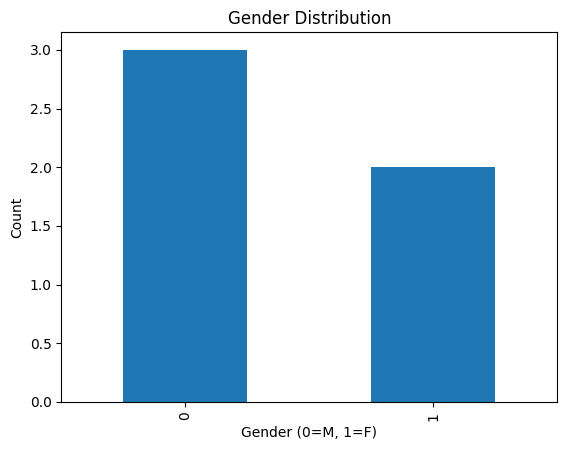

   Id  Age  Gender  Salary  City_London  City_New York  City_Paris  \
0   1   19       1   50000        False           True       False   
1   2   24       0   60000         True          False       False   
2   3   10       1  144600         True          False       False   
3   4   35       0    8000        False          False        True   
4   5   28       0   55000         True          False       False   

   Age_Scaled  Salary_Scaled  Salary_Norm  Age_Norm  
0   -0.578122      -0.464773     0.077491      0.36  
1    0.000000      -0.415643     0.095941      0.56  
2   -1.618741       0.000000     0.252030      0.00  
3    1.271868      -0.671120     0.000000      1.00  
4    0.462497      -0.440208     0.086716      0.72  


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Creating the dataset
raw_data = {
    "Id": [1, 2, 3, 4, 5, 5],
    "Name": ["Simar", "John", "Jashan", "Richa", "Ansan", "Ansan"],
    "Age": [19, np.nan, 10, 35, 28, 28],
    "Gender": ["F", "M", "F", np.nan, "M", "M"],
    "Salary": [50000, 60000, np.nan, 8000, 55000, 550000],
    "City": ["New York", "London", "London", "Paris", np.nan, np.nan]
}

df = pd.DataFrame(raw_data)
print(df)

# --- Understanding the data ---
df.info()
print(df.head(3))
print(df.shape)
print(df.describe(include="all"))
print(df.isnull())
print(df.isnull().sum())

# --- Removing Duplicates ---
df = df.drop_duplicates()

# --- Handling Missing Values ---
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Salary"] = df["Salary"].fillna(df["Salary"].mean())

# Categorical missing values using mode
df["City"] = df["City"].fillna(df["City"].mode()[0])
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

# --- Data Type Conversion ---
df["Age"] = df["Age"].astype(int)
df["Salary"] = df["Salary"].astype(int)

# --- Encode Categorical Variables ---
# Manual mapping for Gender
df["Gender"] = df["Gender"].map({"M": 0, "F": 1})

# One-hot encoding for City
df = pd.get_dummies(df, columns=["City"])

# --- Feature Scaling (Standardization) ---
df["Age_Scaled"] = (df["Age"] - df["Age"].mean()) / df["Age"].std()
df["Salary_Scaled"] = (df["Salary"] - df["Salary"].mean()) / df["Salary"].std()

# --- Normalization (Min-Max Scaling) ---
df["Salary_Norm"] = (df["Salary"] - df["Salary"].min()) / (df["Salary"].max() - df["Salary"].min())
df["Age_Norm"] = (df["Age"] - df["Age"].min()) / (df["Age"].max() - df["Age"].min())

# --- Outlier detection and Removal (IQR Method) ---
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)
IQR = Q3 - Q1

# Filtering outliers
df = df[(df["Salary"] >= Q1 - 1.5 * IQR) & (df["Salary"] <= Q3 + 1.5 * IQR)]

# --- Feature Selection (Drop unnecessary columns) ---
df = df.drop(["Name"], axis=1)
df.reset_index(drop=True, inplace=True)

# --- Bar Graph (Gender) ---
df["Gender"].value_counts().plot(kind="bar")
plt.xlabel("Gender (0=M, 1=F)")
plt.ylabel("Count")
plt.title("Gender Distribution")
plt.show()

print(df)